In [7]:
import numpy as np
import matplotlib.pyplot as plt
import math
from itertools import combinations

In [35]:
def sign(x):
    y = np.sign(x)
    y[y == 0] = 1
    return y

def topk(x, k):

    topk_x = np.zeros_like(x)

    if x.ndim == 1:
        k_indices = np.argsort(x)[-k:]
        topk_x[k_indices] = 1
    
    elif x.ndim == 2:
        k_indices = np.argsort(x, axis=0)[-k:, :]
        col_indices = np.arange(x.shape[1])
        topk_x[k_indices, col_indices] = 1
        
    return topk_x

def k_hot_patterns(NL, k):
    idx_combinations = list(combinations(range(NL), k))
    matrix = np.zeros((NL, len(idx_combinations)))
    for i in range(matrix.shape[1]):
        matrix[:, i][list(idx_combinations[i])] = 1
    return matrix

def get_random_patterns(p, NF):
    patterns = np.zeros((NF, p))
    for i in range(p):
        pattern = np.random.choice([-1, 1], size=NF)
        patterns[:, i] = pattern
    return patterns

def corrupt_pattern(pattern, noise):
    rand_indices = np.where(np.random.rand(pattern.shape[0]) < noise, -1, 1)
    corrupted = pattern * rand_indices
    return corrupted

def get_overlap(state, pattern):
    return np.mean(state * pattern, axis=0)


In [29]:
NL, k = 5, 3
idx_combinations = list(combinations(range(NL), k))
print(idx_combinations)

print(k_hot_patterns(NL, k))

X = np.array([3, 5, 7, 8, 2, 9, 1])
print(topk(X, 3))

[(0, 1, 2), (0, 1, 3), (0, 1, 4), (0, 2, 3), (0, 2, 4), (0, 3, 4), (1, 2, 3), (1, 2, 4), (1, 3, 4), (2, 3, 4)]
[[1. 1. 1. 1. 1. 1. 0. 0. 0. 0.]
 [1. 1. 1. 0. 0. 0. 1. 1. 1. 0.]
 [1. 0. 0. 1. 1. 0. 1. 1. 0. 1.]
 [0. 1. 0. 1. 0. 1. 1. 0. 1. 1.]
 [0. 0. 1. 0. 1. 1. 0. 1. 1. 1.]]
[0 0 1 1 0 1 0]


In [ ]:
def scaffold_layers(NL, NH, C, k):

    W_HL = np.random.normal(0, 1, size=(NH, NL))
    L = k_hot_patterns(NL, k)

    # get hidden layer fixed points
    H = sign(W_HL @ L)
    
    # learn H to L weights
    W_LH = (1/C) * (L @ H.T)

    return L, W_HL, H, W_LH

def scaffold_step(h, W_HL, W_LH, k):
    l = topk(W_LH @ h, k)
    h_step = sign(W_HL @ l)
    return l, h_step

# test
# step with h_mu should return h_mu
NL, NH, k = 5, 8, 3
C = math.comb(NL, k)

L, W_HL, H, W_LH = scaffold_layers(NL, NH, C, k)
print(L, L.shape)
print(H, H.shape)
print(W_LH.shape)
print(W_HL.shape)

h = H[:, 1]
l, h_step = scaffold_step(h, W_HL, W_LH, k)
print(l)
print(h_step - h)

[[1. 1. 1. 1. 1. 1. 0. 0. 0. 0.]
 [1. 1. 1. 0. 0. 0. 1. 1. 1. 0.]
 [1. 0. 0. 1. 1. 0. 1. 1. 0. 1.]
 [0. 1. 0. 1. 0. 1. 1. 0. 1. 1.]
 [0. 0. 1. 0. 1. 1. 0. 1. 1. 1.]] (5, 10)
[[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]
 [-1.  1. -1.  1. -1.  1. -1. -1. -1. -1.]
 [ 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.]
 [-1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]
 [ 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.]
 [ 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.]
 [-1. -1.  1. -1.  1.  1. -1.  1.  1.  1.]
 [-1. -1. -1.  1. -1. -1. -1. -1. -1. -1.]] (8, 10)
(5, 8)
(8, 5)
[1. 1. 0. 1. 0.]
[0. 0. 0. 0. 0. 0. 0. 0.]


In [30]:
def feature_weights(F, H):
    N_patts = F.shape[1]

    #scaffold has n choose k points but we are only storing N_patts patterns, so learn weights with N_patts learned patterns only
    H_till_Npatts = H[:, :N_patts]

    W_HF = H_till_Npatts @ np.linalg.pinv(F)
    W_FH = F @ np.linalg.pinv(H_till_Npatts)

    return W_HF, W_FH

def mesh_recall(f_cued, k, W_HF, W_LH, W_HL, W_FH):
    f = f_cued
    h = sign(W_HF @ f)
    l = topk(W_LH @ h, k)
    h = sign(W_HL @ l)
    f = sign(W_FH @ h)

    return f

NL, NH, NF, k = 10, 40, 100, 3
C = math.comb(NL, k)

N_patts = 20

L, W_HL, H, W_LH = scaffold_layers(NL, NH, C, k)
F = get_random_patterns(N_patts, NF)
W_HF, W_FH = feature_weights(F, H)
print(W_HF.shape, W_FH.shape)

f_cued = corrupt_pattern(F[:, 1], 0.2)
f = mesh_recall(f_cued, k, W_HF, W_LH, W_HL, W_FH)
print(get_overlap(f, F[:, 1]))

(40, 100) (100, 40)
1.0


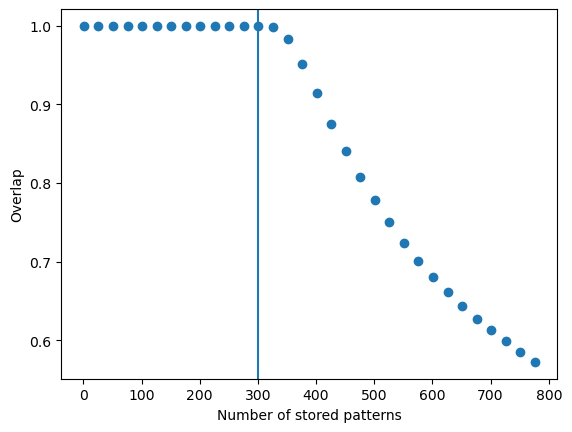

In [ ]:
NL, NH, NF, k = 18, 300, 816, 3
C = math.comb(NL, k)
L, W_HL, H, W_LH = scaffold_layers(NL, NH, C, k)

pattern_range = np.arange(1, 800, 25)
overlap_list = []

for N_patts in pattern_range:
    F = get_random_patterns(N_patts, NF)
    W_HF, W_FH = feature_weights(F, H)
    #F_cued = F * np.where(np.random.rand(F.shape[0], F.shape[1]) < 0.2, -1, 1)
    #F_recalled = mesh_recall(F_cued, k, W_HF, W_LH, W_HL, W_FH)
    F_recalled = mesh_recall(F, k, W_HF, W_LH, W_HL, W_FH)
    overlap = np.mean(get_overlap(F_recalled, F))
    overlap_list.append(overlap)

plt.scatter(pattern_range, overlap_list)
plt.xlabel("Number of stored patterns")
plt.ylabel("Overlap")
plt.axvline(x=NH)
plt.show()